In [82]:
# Import all the libs that we need
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib

In [83]:
df = pd.read_csv("./ethereum_fraud_dataset.csv")

In [84]:
# Fill missing values
df = df.fillna(0)

In [85]:
# Shuffle dataset (unordered flag values (0s and 1s))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [86]:
# Split features and target
X = df.drop("FLAG", axis=1)
y = df["FLAG"]

In [87]:
# Find the ratio of fraud and legit
fraud_count = y.value_counts()[1]
legit_count = y.value_counts()[0]
total = len(df)

fraud_percentage = (fraud_count / total) * 100
legit_percentage = (legit_count / total) * 100

print(f"Fraud Wallets: {fraud_count} ({fraud_percentage:.2f}%)")
print(f"Legit Wallets: {legit_count} ({legit_percentage:.2f}%)")

Fraud Wallets: 2179 (22.14%)
Legit Wallets: 7662 (77.86%)


In [88]:
# Apply SMOTE
smote = SMOTE(
    sampling_strategy=0.67,  # Fraud becomes ~40% compared to legit
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)

# After SMOTE counts
after_counts = Counter(y_resampled)

after_legit = after_counts[0]
after_fraud = after_counts[1]
after_total = after_legit + after_fraud

after_legit_percentage = (after_legit / after_total) * 100
after_fraud_percentage = (after_fraud / after_total) * 100

print("=== AFTER SMOTE ===")
print(f"Legit Wallets: {after_legit} ({after_legit_percentage:.2f}%)")
print(f"Fraud Wallets: {after_fraud} ({after_fraud_percentage:.2f}%)")

=== AFTER SMOTE ===
Legit Wallets: 7662 (59.88%)
Fraud Wallets: 5133 (40.12%)


In [89]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
X_resampled,
y_resampled,
test_size=0.3,
random_state=42,
stratify=y_resampled
)

In [90]:
# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [91]:
# Predict
y_pred = model.predict(X_test)

In [92]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 94.53%


In [93]:
# 5. Full performance report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legit", "Fraud"]
))

              precision    recall  f1-score   support

       Legit       0.95      0.96      0.95      2299
       Fraud       0.94      0.92      0.93      1540

    accuracy                           0.95      3839
   macro avg       0.94      0.94      0.94      3839
weighted avg       0.95      0.95      0.95      3839



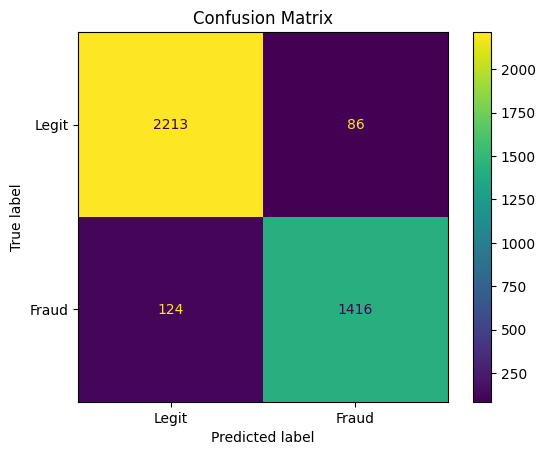

In [94]:
# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legit", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [95]:
# 7. Save model
joblib.dump(model, "crypto_fraud_model.pkl")

['crypto_fraud_model.pkl']